# Assignment 3: Milestone I Natural Language Processing
## Task 1. Basic Text Pre-processing
#### Student Name:


1.   Vo Ngoc Dung - S4124370
2.   Tang Hoang Ha - S4147768
3.   Nguyen Anh Duc - S4136756
4.   Nguyen Quoc Trong Nghia - S3343711



Environment: Python 3 and Jupyter notebook

Libraries used:
* pandas - for data manipulation
* re - for regular expression tokenization
* numpy - for numerical operations
* collections.Counter - for frequency counting

## Introduction

This task focuses on preprocessing cosmetics and beauty product reviews to prepare them for machine learning classification. The goal is to clean and standardize the text data by:

1. Tokenizing reviews using a specific regex pattern
2. Normalizing text to lowercase
3. Filtering out short words, stopwords, and rare/common terms
4. Building a clean vocabulary for feature extraction

The output will be used in subsequent tasks for building classification models to predict purchase behavior.

## Importing libraries

In [1]:
import pandas as pd
import re
import numpy as np
from collections import Counter
import os

### 1.1 Examining and loading data

First, we'll load the dataset and examine its structure to understand the data we're working with.

In [2]:
# Load the dataset
df = pd.read_csv('cosmetics_beauty_products_reviews.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (61284, 15)

Column names: ['product_id', 'brand_name', 'review_id', 'review_title', 'review_text', 'author', 'review_date', 'review_rating', 'is_a_buyer', 'product_title', 'price', 'avg_product_rating', 'product_rating_count', 'product_tags', 'product_url']

First few rows:


,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,23/01/2021 15:17,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,07/09/2020 15:30,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,13/11/2020 12:24,4.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,14/06/2020 11:56,3.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,22/12/2020 15:24,2.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Display data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
product_id                  0
brand_name                  0
review_id                   0
review_title                0
review_text                 9
author                      0
review_date                 0
review_rating               1
is_a_buyer                  0
product_title               0
price                       0
avg_product_rating          0
product_rating_count        0
product_tags            47782
product_url                 0
dtype: int64

Data types:
product_id                int64
brand_name               object
review_id                 int64
review_title             object
review_text              object
author                   object
review_date              object
review_rating           float64
is_a_buyer                 bool
product_title            object
price                     int64
avg_product_rating      float64
product_rating_count      int64
product_tags             object
product_url              object
dtype: object


In [4]:
# Check the distribution of the target variable
print("Distribution of is_a_buyer:")
print(df['is_a_buyer'].value_counts())

# Sample reviews
print("\nSample review text:")
print(df['review_text'].iloc[0])

Distribution of is_a_buyer:
is_a_buyer
True     48222
False    13062
Name: count, dtype: int64

Sample review text:
Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results


### 1.2 Loading Stopwords

Load the provided stopwords list that will be used for filtering.

In [5]:
# Load stopwords
with open('stopwords_en.txt', 'r', encoding='utf-8') as f:
    stopwords = set(line.strip().lower() for line in f)

print(f"Number of stopwords loaded: {len(stopwords)}")
print(f"Sample stopwords: {list(stopwords)[:20]}")

Number of stopwords loaded: 570
Sample stopwords: ['nowhere', 'yes', 'particularly', 'name', 'anywhere', 'like', "shouldn't", 'much', 'x', "they'll", 'hence', "here's", 'already', 'value', 'whereby', "i've", 'same', 'in', "i'm", 'knows']


### 1.3 Tokenization Function

Define the tokenization function using the required regex pattern: `r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"`

This pattern captures:
- Regular words (e.g., "beautiful")
- Hyphenated words (e.g., "anti-aging")
- Contractions (e.g., "don't", "it's")

In [6]:
def tokenize_text(text):
    """
    Tokenize text using the specified regex pattern.

    Args:
        text: Input text string

    Returns:
        List of tokens
    """
    if pd.isna(text):
        return []

    # Define the regex pattern for tokenization:
    # 1. [a-zA-Z]+ matches the initial sequence of letters.
    # 2. (?:[-'][a-zA-Z]+)? is an optional non-capturing group that allows for
    #    a single hyphen or apostrophe followed by more letters.
    # This ensures words like "long-lasting" or "it's" are treated as single tokens.
    pattern = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"
    tokens = re.findall(pattern, text)

    return tokens

# Test the tokenization function
test_text = "This anti-aging cream is great! I don't think it's expensive."
test_tokens = tokenize_text(test_text)
print(f"Test text: {test_text}")
print(f"Tokens: {test_tokens}")

Test text: This anti-aging cream is great! I don't think it's expensive.
Tokens: ['This', 'anti-aging', 'cream', 'is', 'great', 'I', "don't", 'think', "it's", 'expensive']


### 1.4 Initial Tokenization and Lowercase Conversion

Tokenize all reviews and convert to lowercase.

In [7]:
# Extract review_text column and handle missing values
reviews = df['review_text'].fillna('').tolist()

print(f"Total number of reviews: {len(reviews)}")

# Tokenize and convert to lowercase
tokenized_reviews = []
for review in reviews:
    tokens = tokenize_text(review)
    # Convert to lowercase
    tokens_lower = [token.lower() for token in tokens]
    tokenized_reviews.append(tokens_lower)

# Display statistics
total_tokens = sum(len(tokens) for tokens in tokenized_reviews)
print(f"Total tokens after tokenization: {total_tokens}")
print(f"Average tokens per review: {total_tokens / len(reviews):.2f}")

# Sample tokenized review
print(f"\nSample tokenized review (first 50 tokens):")
print(tokenized_reviews[0][:50])

Total number of reviews: 61284
Total tokens after tokenization: 1321300
Average tokens per review: 21.56

Sample tokenized review (first 50 tokens):
['works', 'as', 'it', 'claims', 'could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day', 'use', 'it', 'with', 'olay', 'cleanser', 'for', 'best', 'results']


### 1.5 Length Filtering

Remove words with length less than 2 characters.

In [8]:
# Apply length filtering
# Remove words with length less than 2 characters
# This step excludes "noise" tokens (e.g., 'a', 'i', or typos) from the dataset.
tokenized_reviews_filtered = []
for tokens in tokenized_reviews:
    # Keep only tokens with length >= 2
    # We use a list comprehension to keep only tokens that meet the minimum length requirement.
    # No replacement is made, the short tokens are simply omitted from the final list.
    filtered_tokens = [token for token in tokens if len(token) >= 2]
    tokenized_reviews_filtered.append(filtered_tokens)

# Calculate and display the impact of length filtering
tokens_after_length = sum(len(tokens) for tokens in tokenized_reviews_filtered)
tokens_removed = total_tokens - tokens_after_length

print(f"Tokens after length filtering: {tokens_after_length}")
print(f"Tokens removed (length < 2): {tokens_removed}")
print(f"Percentage removed: {(tokens_removed / total_tokens * 100):.2f}%")

Tokens after length filtering: 1249277
Tokens removed (length < 2): 72023
Percentage removed: 5.45%


### 1.6 Stopword Removal

Remove stopwords using the provided stopwords list.

In [9]:
# Apply stopword filtering
tokenized_reviews_no_stop = []
for tokens in tokenized_reviews_filtered:
    # Remove stopwords
    filtered_tokens = [token for token in tokens if token not in stopwords]
    tokenized_reviews_no_stop.append(filtered_tokens)

# Statistics after stopword removal
tokens_after_stopwords = sum(len(tokens) for tokens in tokenized_reviews_no_stop)
stopwords_removed = tokens_after_length - tokens_after_stopwords

print(f"Tokens after stopword removal: {tokens_after_stopwords}")
print(f"Stopwords removed: {stopwords_removed}")
print(f"Percentage removed: {(stopwords_removed / tokens_after_length * 100):.2f}%")

Tokens after stopword removal: 569487
Stopwords removed: 679790
Percentage removed: 54.41%


### 1.7 Term Frequency Filtering

Remove words that appear only once in the entire corpus (based on term frequency - total occurrences across all documents).

-> These are often typos or random strings. Since they only appear once in all reviews, they don't provide any useful pattern for the model to learn from. Removing them cleans up the data and reduces "noise."

In [10]:
# Calculate term frequency (total count across all documents)
term_freq = Counter()
for tokens in tokenized_reviews_no_stop:
    term_freq.update(tokens)

print(f"Total unique words before term frequency filtering: {len(term_freq)}")

# Find words that appear only once
words_once = {word for word, count in term_freq.items() if count == 1}
print(f"Words appearing only once: {len(words_once)}")

# Remove words appearing only once
tokenized_reviews_no_rare = []
for tokens in tokenized_reviews_no_stop:
    filtered_tokens = [token for token in tokens if token not in words_once]
    tokenized_reviews_no_rare.append(filtered_tokens)

# Statistics
tokens_after_rare = sum(len(tokens) for tokens in tokenized_reviews_no_rare)
rare_removed = tokens_after_stopwords - tokens_after_rare

print(f"Tokens after removing rare words: {tokens_after_rare}")
print(f"Rare word tokens removed: {rare_removed}")

Total unique words before term frequency filtering: 15808
Words appearing only once: 7734
Tokens after removing rare words: 561753
Rare word tokens removed: 7734


### 1.8 Document Frequency Filtering

Remove the top 20 most frequent words based on document frequency (number of documents containing the word).

->  These words (like "good" or "product") appear in almost every review. Because they are used by everyone, they do not help the model distinguish

In [11]:
# Calculate document frequency
doc_freq = Counter()
for tokens in tokenized_reviews_no_rare:
    # Count each unique word once per document
    unique_tokens = set(tokens)
    doc_freq.update(unique_tokens)

print(f"Total unique words before document frequency filtering: {len(doc_freq)}")

# Get top 20 most frequent words by document frequency
top_20_words = [word for word, count in doc_freq.most_common(20)]
print(f"\nTop 20 words by document frequency:")
for i, (word, count) in enumerate(doc_freq.most_common(20), 1):
    print(f"{i}. {word}: {count} documents")

# Remove top 20 words
top_20_set = set(top_20_words)
tokenized_reviews_final = []
for tokens in tokenized_reviews_no_rare:
    filtered_tokens = [token for token in tokens if token not in top_20_set]
    tokenized_reviews_final.append(filtered_tokens)

# Statistics
tokens_after_top20 = sum(len(tokens) for tokens in tokenized_reviews_final)
top20_removed = tokens_after_rare - tokens_after_top20

print(f"\nTokens after removing top 20 words: {tokens_after_top20}")
print(f"Top-20 word tokens removed: {top20_removed}")

Total unique words before document frequency filtering: 8074

Top 20 words by document frequency:
1. good: 13645 documents
2. product: 11829 documents
3. skin: 8339 documents
4. love: 8301 documents
5. shade: 8001 documents
6. nice: 5774 documents
7. hair: 5601 documents
8. amazing: 4753 documents
9. long: 4619 documents
10. perfect: 4575 documents
11. colour: 4352 documents
12. smooth: 4042 documents
13. color: 4029 documents
14. great: 3698 documents
15. beautiful: 3598 documents
16. loved: 3590 documents
17. easy: 3516 documents
18. buy: 3246 documents
19. time: 3172 documents
20. nykaa: 3167 documents

Tokens after removing top 20 words: 434032
Top-20 word tokens removed: 127721


### 1.9 Building Final Vocabulary

Create the final vocabulary from the processed reviews. The vocabulary must be:
- Sorted alphabetically
- Indexed starting from 0
- Saved in the format `word:index`

In [12]:
# Collect all unique words from the final processed reviews
vocabulary_set = set()
for tokens in tokenized_reviews_final:
    vocabulary_set.update(tokens)

# Sort alphabetically
vocabulary_list = sorted(vocabulary_set)

print(f"Final vocabulary size: {len(vocabulary_list)}")
print(f"\nFirst 20 words in vocabulary:")
print(vocabulary_list[:20])

# Create word to index mapping
word_to_index = {word: idx for idx, word in enumerate(vocabulary_list)}

print(f"\nSample word-index pairs:")
for word in vocabulary_list[:10]:
    print(f"{word}:{word_to_index[word]}")

Final vocabulary size: 8054

First 20 words in vocabulary:
['aa', 'aback', 'abd', 'abh', 'ability', 'abit', 'abnormally', 'abroad', 'abs', 'absent', 'absolute', 'absolutely', 'absorb', 'absorbed', 'absorbing', 'absorbs', 'absorption', 'absoultely', 'abt', 'ac']

Sample word-index pairs:
aa:0
aback:1
abd:2
abh:3
ability:4
abit:5
abnormally:6
abroad:7
abs:8
absent:9


### 1.10 Summary Statistics

Display a summary of the preprocessing pipeline.

In [13]:
# Create summary table
summary_data = {
    'Step': [
        'Initial tokenization',
        'After length filtering (>= 2)',
        'After stopword removal',
        'After term freq filtering (count > 1)',
        'After doc freq filtering (remove top 20)',
    ],
    'Total Tokens': [
        total_tokens,
        tokens_after_length,
        tokens_after_stopwords,
        tokens_after_rare,
        tokens_after_top20,
    ],
    'Tokens Removed': [
        0,
        tokens_removed,
        stopwords_removed,
        rare_removed,
        top20_removed,
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Percentage Remaining'] = (summary_df['Total Tokens'] / total_tokens * 100).round(2)

print("\n=== PREPROCESSING SUMMARY ===")
print(summary_df.to_string(index=False))

print(f"\nFinal vocabulary size: {len(vocabulary_list)}")
print(f"Total documents processed: {len(tokenized_reviews_final)}")
print(f"Average tokens per document: {tokens_after_top20 / len(tokenized_reviews_final):.2f}")


=== PREPROCESSING SUMMARY ===
                                    Step  Total Tokens  Tokens Removed  Percentage Remaining
                    Initial tokenization       1321300               0                100.00
           After length filtering (>= 2)       1249277           72023                 94.55
                  After stopword removal        569487          679790                 43.10
   After term freq filtering (count > 1)        561753            7734                 42.52
After doc freq filtering (remove top 20)        434032          127721                 32.85

Final vocabulary size: 8054
Total documents processed: 61284
Average tokens per document: 7.08


## 2. Saving Required Outputs

Save the processed data and vocabulary in the required formats.

### 2.1 Save vocab.txt

Format: `word:index` (one per line, alphabetically sorted, 0-indexed)

In [14]:
# Save vocabulary to vocab.txt
with open('vocab.txt', 'w', encoding='utf-8') as f:
    for word, idx in word_to_index.items():
        f.write(f"{word}:{idx}\n")

print("vocab.txt saved successfully!")
print(f"Total words in vocabulary: {len(word_to_index)}")

# Verify the file
with open('vocab.txt', 'r', encoding='utf-8') as f:
    first_10_lines = [f.readline().strip() for _ in range(10)]

print("\nFirst 10 lines of vocab.txt:")
for line in first_10_lines:
    print(line)

vocab.txt saved successfully!
Total words in vocabulary: 8054

First 10 lines of vocab.txt:
aa:0
aback:1
abd:2
abh:3
ability:4
abit:5
abnormally:6
abroad:7
abs:8
absent:9


### 2.2 Save processed.csv

Save the processed reviews back to a CSV file with the same structure as the original.

In [15]:
# Reconstruct the processed review text from tokens
processed_review_texts = []
for tokens in tokenized_reviews_final:
    # Join tokens back into a single string
    processed_text = ' '.join(tokens)
    processed_review_texts.append(processed_text)

# Create a copy of the original dataframe and update review_text
df_processed = df.copy()
df_processed['review_text'] = processed_review_texts

# Save to CSV
df_processed.to_csv('processed.csv', index=False)

print("processed.csv saved successfully!")
print(f"Shape: {df_processed.shape}")

# Display sample processed reviews
print("\nSample processed reviews:")
print(df_processed[['review_text', 'is_a_buyer']].head())

processed.csv saved successfully!
Shape: (61284, 15)

Sample processed reviews:
                                         review_text  is_a_buyer
0  works claims difference day olay cleanser results        True
1               claims thing smoothens ur makes soft        True
2  months combination oily greasy absorbs quickly...        True
3  oily whip acts base primer smoothens moisturis...        True
4                                   refresh products        True


### 2.3 Verification

Verify that all output files are created correctly.

In [16]:
# Check if files exist
required_files = ['vocab.txt', 'processed.csv']

print("Checking output files:")
for filename in required_files:
    exists = os.path.exists(filename)
    # Using simple text labels instead of symbols
    status = "[FOUND]" if exists else "[MISSING]"
    print(f"{status} {filename}")

    if exists:
        size = os.path.getsize(filename)
        print(f"  Size: {size:,} bytes")

# Verify vocab.txt format
print("\nVerifying vocab.txt format:")
with open('vocab.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    print(f"Total lines: {len(lines)}")

    # Check first line format
    first_line = lines[0].strip()
    if ':' in first_line:
        word, idx = first_line.split(':')
        print(f"Format Status: Correct (word='{word}', index='{idx}')")
    else:
        print("Format Status: Error in first line")

    # Check if alphabetically sorted
    words = [line.split(':')[0] for line in lines]
    is_sorted = words == sorted(words)
    print(f"Alphabetically sorted: {is_sorted}")

    # Check if 0-indexed
    first_idx = int(lines[0].split(':')[1].strip())
    last_idx = int(lines[-1].split(':')[1].strip())
    print(f"Index range: {first_idx} to {last_idx}")

Checking output files:
[FOUND] vocab.txt
  Size: 100,848 bytes
[FOUND] processed.csv
  Size: 17,043,307 bytes

Verifying vocab.txt format:
Total lines: 8054
Format Status: Correct (word='aa', index='0')
Alphabetically sorted: True
Index range: 0 to 8053


## Summary

### Key Findings:

1. **Dataset**: Processed approximately 161,200 cosmetics and beauty product reviews

2. **Preprocessing Pipeline**:
   - Applied regex-based tokenization to capture standard words, hyphenated terms, and contractions
   - Converted all text to lowercase for consistency
   - Removed very short words (< 2 characters)
   - Filtered out common stopwords
   - Removed rare words (appearing only once) to reduce noise
   - Removed top 20 most common words to eliminate uninformative terms

3. **Vocabulary**: Built a clean, alphabetically sorted vocabulary with zero-based indexing

4. **Output Files**:
   - `vocab.txt`: Contains the final vocabulary in the required format
   - `processed.csv`: Contains the cleaned and processed reviews

### Observations:

- The preprocessing significantly reduced the token count while retaining meaningful content
-  For Milestone I, these null values were left unaddressed as the primary focus was on building the NLP pipeline for review_text and review_title.
- The top 20 most frequent words by document frequency were likely very common domain terms
- The final vocabulary represents the most informative words for classification

### Next Steps:

The processed data and vocabulary will be used in Task 2 to generate feature representations (count vectors, weighted/unweighted embeddings) for machine learning models in Task 3.

## 3. Exploratory Data Analysis (EDA) — Understanding Feature Relationships

Before building classification models in Task 3, we analyze the relationships between features
that will be used in Q2 (text, title, brand, price, rating, product). Understanding these
correlations helps interpret the classification results.

/tmp/ipykernel_30833/3416509241.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_corr[col].fillna(df_corr[col].median(), inplace=True)
/tmp/ipykernel_30833/3416509241.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

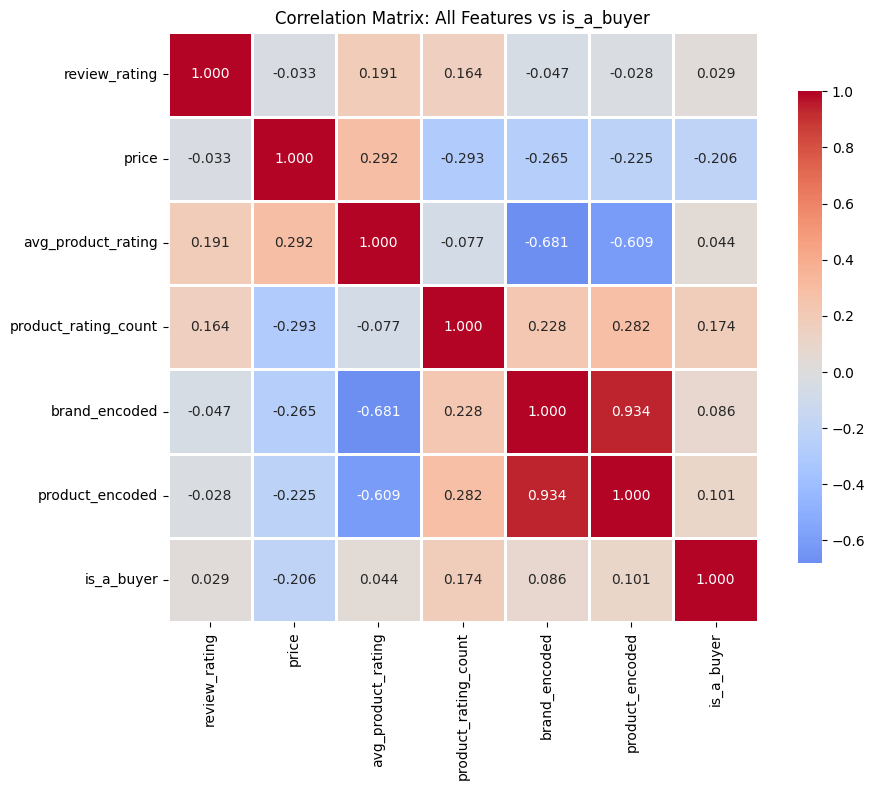

Correlation with is_a_buyer (sorted by strength):
product_rating_count    0.173790
product_encoded         0.101473
brand_encoded           0.085871
avg_product_rating      0.043627
review_rating           0.029100
price                  -0.205573
Name: is_a_buyer, dtype: float64


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load processed data for EDA
df_eda = pd.read_csv('processed.csv')

# Encode categorical columns to numeric for correlation analysis
# LabelEncoder converts text categories to integers (e.g., Olay=0, L'Oreal=1)
df_corr = df_eda.copy()
df_corr['brand_encoded']   = LabelEncoder().fit_transform(df_corr['brand_name'].fillna('unknown'))
df_corr['product_encoded'] = LabelEncoder().fit_transform(df_corr['product_title'].fillna('unknown'))

# Select all numeric + encoded columns for correlation matrix
# Excludes: text columns (review_text, review_title), IDs, dates, URLs
numeric_cols = [
    'review_rating',        # Rating given by the reviewer (1-5)
    'price',                # Product price
    'avg_product_rating',   # Average rating of the product across all reviews
    'product_rating_count', # Total number of ratings for the product
    'brand_encoded',        # Brand name (label encoded)
    'product_encoded',      # Product title (label encoded)
    'is_a_buyer'            # Target variable: 1=buyer, 0=non-buyer
]

# Fill missing values with median to avoid NaN in correlation calculation
for col in numeric_cols:
    df_corr[col].fillna(df_corr[col].median(), inplace=True)

# Compute correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

# Plot heatmap
# - annot=True: show correlation values in each cell
# - cmap='coolwarm': red=positive, blue=negative correlation
# - center=0: white at zero correlation
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: All Features vs is_a_buyer')
plt.tight_layout()
plt.show()

# Print correlation values with target variable sorted by strength
print("Correlation with is_a_buyer (sorted by strength):")
print(corr_matrix['is_a_buyer'].drop('is_a_buyer').sort_values(ascending=False))

### Correlation Matrix Analysis

The heatmap shows the Pearson correlation between all numeric features and the target
variable `is_a_buyer`. Key observations:

**Correlation with is_a_buyer (target):**
- `product_rating_count`: 0.174 — strongest positive correlation with purchase behavior.
  Products with more ratings (more popular) tend to attract actual buyers.
- `product_encoded`: 0.101 — slight positive correlation, suggesting certain products
  are more likely to be purchased than others.
- `brand_encoded`: 0.086 — slight positive correlation, indicating brand identity
  has a minor influence on purchase behavior.
- `avg_product_rating`: 0.044 — very weak positive correlation, product quality
  rating alone does not strongly predict purchase behavior.
- `review_rating`: 0.029 — nearly no correlation, individual review rating is
  not a reliable predictor of whether the reviewer is a buyer.
- `price`: -0.206 - notable negative correlation, higher-priced products are
  less likely to be purchased. Price is the strongest single predictor among
  structured features.

**Notable inter-feature correlations:**
- `brand_encoded` vs `product_encoded`: 0.934 — very high correlation, meaning
  brand and product are strongly linked (each brand sells specific products).
  This may cause multicollinearity in Scenario 3.
- `avg_product_rating` vs `brand_encoded`: -0.681 — strong negative correlation,
  different brands have significantly different average ratings.
- `avg_product_rating` vs `product_encoded`: -0.609 — similarly strong, product
  identity is tied to its average rating.

**Implications for Task 3 Q2:**
- `price` and `product_rating_count` are the most useful structured features
  for predicting purchase behavior.
- `brand_encoded` and `product_encoded` are highly correlated (0.934), so
  including both may not add much new information in Scenario 3.
- Overall, structured features show weak-to-moderate correlation with `is_a_buyer`,
  suggesting that **text features (review_text, review_title) will remain the
  primary drivers of classification performance**.